<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        108 non-null    object 
 1   weight      108 non-null    float64
 2   health      108 non-null    int64  
 3   value       108 non-null    int64  
 4   min_damage  108 non-null    int64  
 5   max_damage  108 non-null    int64  
 6   speed       108 non-null    float64
 7   reach       108 non-null    float64
 8   enchant     106 non-null    float64
 9   style       108 non-null    object 
 10  grip        108 non-null    object 
 11  magic       108 non-null    object 
 12  make        108 non-null    object 
dtypes: float64(4), int64(4), object(5)
memory usage: 11.1+ KB
Index(['name', 'weight', 'health', 'value', 'min_damage', 'max_damage',
       'speed', 'reach', 'enchant', 'style', 'grip', 'magic', 'make'],
      dtype='object')


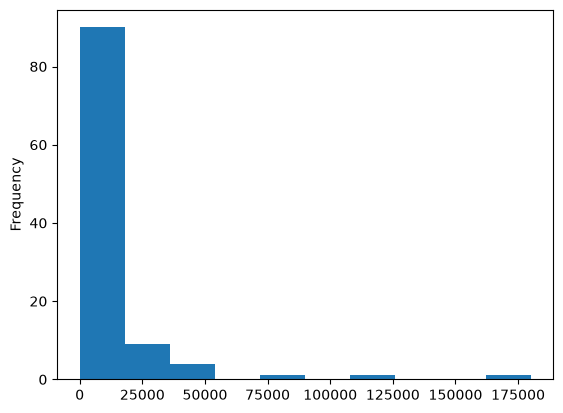

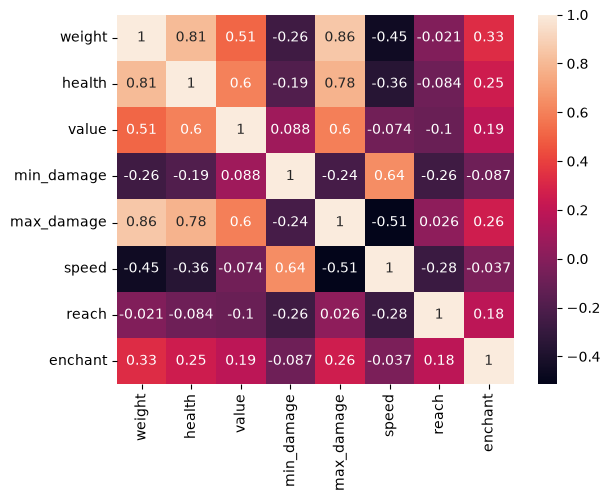

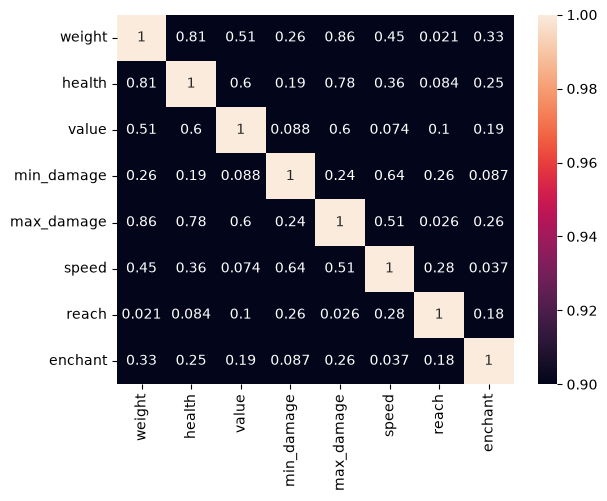

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data
df = pd.read_csv('../data/morrowind_weapons.csv', encoding='latin-1')
df.head()
df.info()
df = df.dropna()

print(df.columns)

# output is value feature
random_state = 123857

# histo
df['value'].plot(kind='hist')
plt.show()

# corr
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

# colinearity
corr = df.corr(numeric_only=True).abs()
sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
plt.show()

Mean Train Score: -0.4074
Mean Test Score:  -290.1807


c:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.551e+06, tolerance: 6.798e+04
  model = cd_fast.enet_coordinate_descent(
c:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.551e+06, tolerance: 6.798e+04
  model = cd_fast.enet_coordinate_descent(
c:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.551e+06, tolerance: 6.798e+04
  model = cd_fast.enet_coordinat

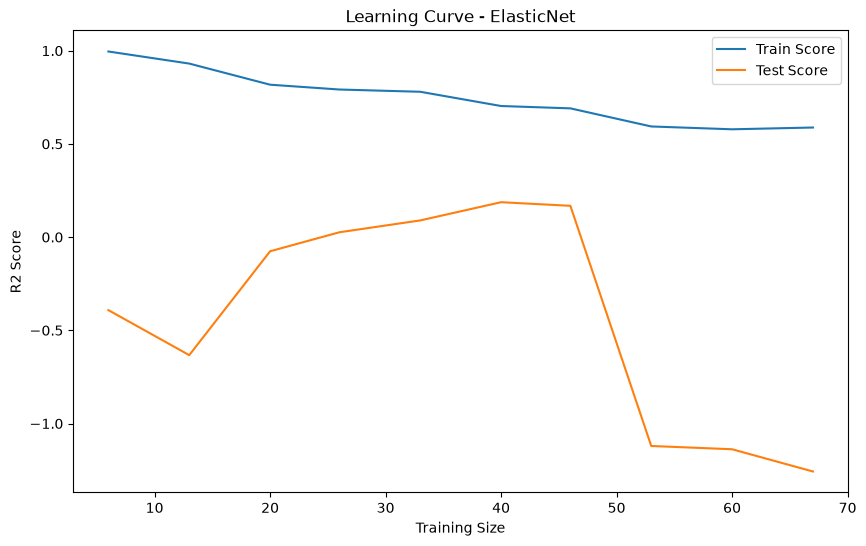

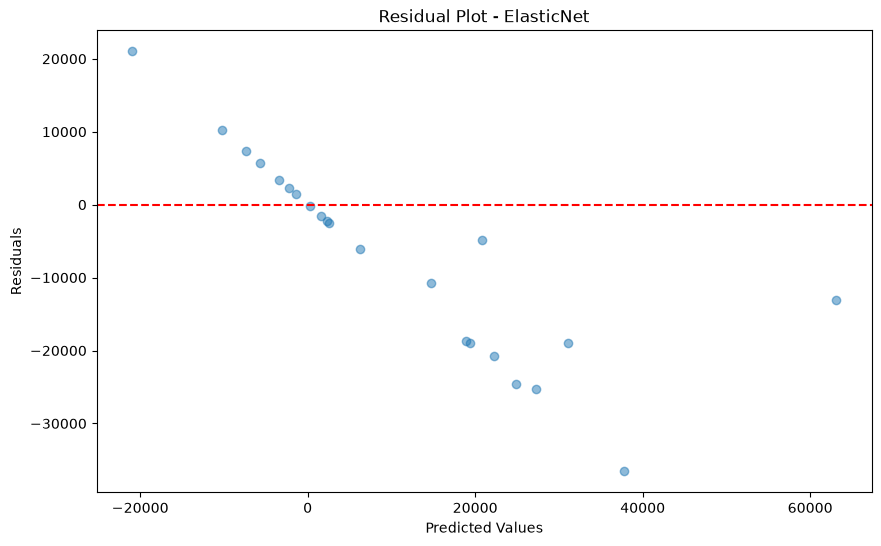

c:\python\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.855e+09, tolerance: 5.085e+06 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\python\Lib\site-packages\sklear

Best Alpha: {'alpha': 100}
Best Score: -1.1486


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# encode categorical columns first
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['value', 'name']]

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# separate X and y
X = df.drop(columns=['value', 'name', 'style', 'grip', 'magic', 'make'])
y = df['value']

# fit kmeans on full X
kmeans = KMeans(n_clusters=5, random_state=random_state)
df['cluster'] = kmeans.fit_predict(X)

# resplit with encoding
X = df.drop(columns=['value', 'name'])
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=random_state, test_size=0.2)

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

model_en = ElasticNet()

train_scores = cross_val_score(model_en, X_train, y_train, cv=kf, scoring='r2')
test_scores = cross_val_score(model_en, X_test, y_test, cv=kf, scoring='r2')

print(f'Mean Train Score: {train_scores.mean():.4f}')
print(f'Mean Test Score:  {test_scores.mean():.4f}')

from sklearn.model_selection import learning_curve, GridSearchCV
import numpy as np

### LEARNING CURVE
train_sizes, train_scores, test_scores = learning_curve(
    ElasticNet(), X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2'
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), label='Train Score')
ax.plot(train_sizes, test_scores.mean(axis=1), label='Test Score')
ax.set_title('Learning Curve - ElasticNet')
ax.set_xlabel('Training Size')
ax.set_ylabel('R2 Score')
ax.legend()
plt.show()

### RESIDUAL PLOT
model_en = ElasticNet()
model_en.fit(X_train, y_train)
y_pred = model_en.predict(X_test)
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred, residuals, alpha=0.5)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_title('Residual Plot - ElasticNet')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Residuals')
plt.show()

### GRIDSEARCHCV
param_grid = {'alpha': list(range(0, 101))}

grid_search = GridSearchCV(ElasticNet(), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print(f'Best Alpha: {grid_search.best_params_}')
print(f'Best Score: {grid_search.best_score_:.4f}')

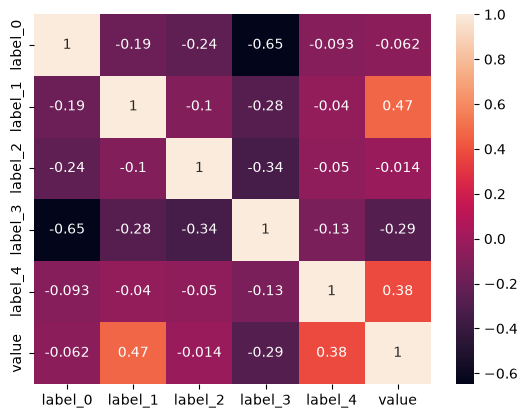

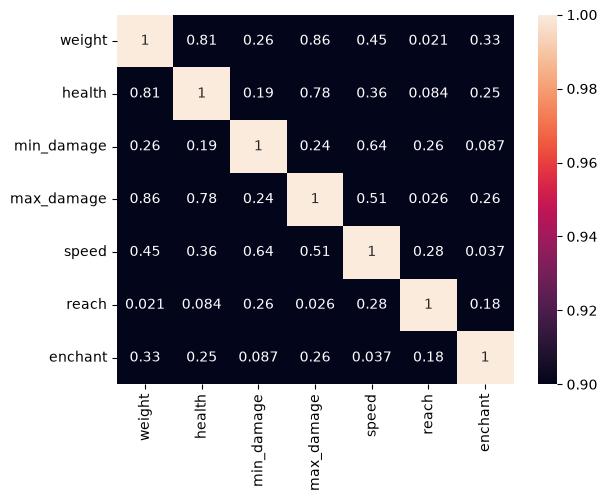

Best feature: health


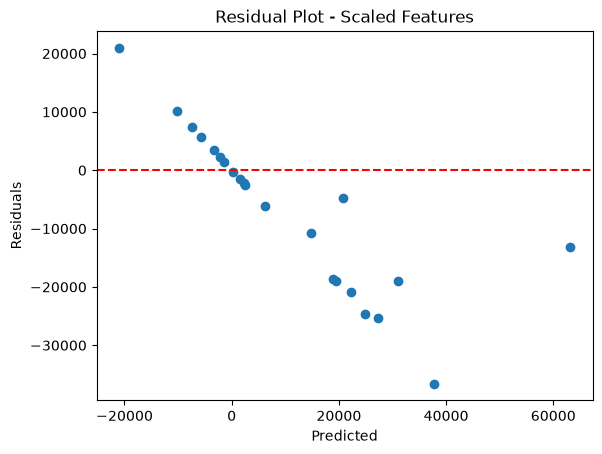

In [51]:
##### LAB QUESTIONS START

import seaborn as sns
df = pd.get_dummies(df, columns=['cluster'], prefix='label')
corr = df[['label_0', 'label_1', 'label_2', 'label_3', 'label_4', 'value']].corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

# check coliearity
corr = X.drop(columns=['style', 'cluster', 'make', 'magic', 'grip']).corr(numeric_only=True).abs()
sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
plt.show()

# SelectK 
from sklearn.feature_selection import SelectKBest, f_regression
kselect = SelectKBest(k=1, score_func=f_regression)
X_best = kselect.fit_transform(X, y)
best_feature = X.columns[kselect.get_support()][0]
print(f'Best feature: {best_feature}')

# residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot - Scaled Features')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()